# Hito 1 — F1 Race Strategy Advisor: Baseline

**Team:** Group 18 — Alonso Cárdenas, Benjamín Sánchez  
**Target:** `is_top10` (locked)  
**Split:** Train 2019–2021 / Calibration 2022 / Test 2023–2024  
**Primary metric:** Brier Score

In [1]:
# Cell 1 - Imports & seed
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Imports OK - sklearn with FrozenEstimator for calibration')

Imports OK - sklearn with FrozenEstimator for calibration


In [2]:
# Cell 2 - Load data
df = pd.read_csv('data/f1_strategy_race_level.csv')
print(f'Shape: {df.shape}')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'\nis_top10 distribution:\n{df["is_top10"].value_counts(normalize=True).round(3)}')
df.head(3)

Shape: (2447, 47)
Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

is_top10 distribution:
is_top10
1    0.516
0    0.484
Name: proportion, dtype: float64


,season,round,race_name,circuit_id,circuit,circuit_type,driver_id,driver_name,Driver,Team,...,avg_track_temp,avg_air_temp,finish_position,points,positions_gained,is_top3,is_top5,is_top10,dnf,status
0,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,bottas,Bottas,BOT,Mercedes,...,40.300000,23.329091,1,26.0,1.0,1,1,1,0,Finished
1,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,hamilton,Hamilton,HAM,Mercedes,...,40.260000,23.330909,2,18.0,-1.0,1,1,1,0,Finished
2,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,max_verstappen,Verstappen,VER,Red Bull,...,40.276364,23.334545,3,15.0,1.0,1,1,1,0,Finished


In [3]:
# Cell 3 - Temporal split (LOCKED)
train = df[df['season'].isin([2019, 2020, 2021])].copy()
cal   = df[df['season'] == 2022].copy()
test  = df[df['season'].isin([2023, 2024])].copy()

print(f'Train: {len(train)} rows, seasons {sorted(train["season"].unique())}')
print(f'Cal:   {len(cal)} rows, seasons {sorted(cal["season"].unique())}')
print(f'Test:  {len(test)} rows, seasons {sorted(test["season"].unique())}')
print(f'\nTotal: {len(train)+len(cal)+len(test)} (of {len(df)})')
print(f'\nis_top10 rates - Train: {train["is_top10"].mean():.3f}, Cal: {cal["is_top10"].mean():.3f}, Test: {test["is_top10"].mean():.3f}')

Train: 1132 rows, seasons [np.int64(2019), np.int64(2020), np.int64(2021)]
Cal:   426 rows, seasons [np.int64(2022)]
Test:  889 rows, seasons [np.int64(2023), np.int64(2024)]

Total: 2447 (of 2447)

is_top10 rates - Train: 0.515, Cal: 0.516, Test: 0.517


## Leakage Audit

Every column in the dataset classified into one of three categories.

In [4]:
# Cell 4 - Leakage audit
leakage_audit = {
    'pre_race': [
        'season', 'round', 'race_name', 'circuit_id', 'circuit', 'circuit_type',
        'driver_id', 'driver_name', 'Driver', 'Team', 'constructor_name',
        'grid_position', 'qualifying_position',
        'driver_prior3_avg_finish', 'constructor_prior3_avg_finish',
        'driver_circuit_prior_avg', 'constructor_tier'
    ],
    'scenario_inputs': [
        'n_stops', 'strategy_type', 'compound_sequence',
        'stint_lengths', 'stint1_length', 'stint2_length', 'stint3_length',
        'stint4_length', 'stint5_length', 'avg_pit_stop_duration_s',
        'total_pit_time_s', 'first_pit_lap', 'last_pit_lap'
    ],
    'post_race_audit_only': [
        'qualifying_time_s',
        'track_status_summary', 'safety_car_periods', 'safety_car_laps',
        'vsc_laps', 'weather_actual', 'wet_laps',
        'avg_track_temp', 'avg_air_temp',
        'finish_position', 'points', 'positions_gained',
        'is_top3', 'is_top5', 'is_top10', 'dnf', 'status'
    ]
}

print('=== LEAKAGE AUDIT ===')
for cat, cols in leakage_audit.items():
    print(f'\n{cat.upper()} ({len(cols)} columns):')
    for c in cols:
        exists = '[OK]' if c in df.columns else '[MISSING]'
        print(f'  {exists} {c}')

all_audited = set()
for cols in leakage_audit.values():
    all_audited.update(cols)
missing = set(df.columns) - all_audited
print(f'\nUnaudited columns: {missing if missing else "None - all columns classified"}')

print('\n--- KEY DECLARATION ---')
print('Strategy features (n_stops, compound_sequence, stint_lengths, etc.) are POST-RACE')
print('observations in the raw data. For this capstone they are ALLOWED as SCENARIO INPUTS')
print('because the product is a what-if comparison tool. The user intentionally sets these')
print('variables. They are NOT pre-race predictions.')
print('\nSafety car, weather, and track status columns are AUDIT-ONLY. They cannot be used')
print('as predictors - only for post-hoc error analysis or scenario stress tests.')

=== LEAKAGE AUDIT ===

PRE_RACE (17 columns):
  [OK] season
  [OK] round
  [OK] race_name
  [OK] circuit_id
  [OK] circuit
  [OK] circuit_type
  [OK] driver_id
  [OK] driver_name
  [OK] Driver
  [OK] Team
  [OK] constructor_name
  [OK] grid_position
  [OK] qualifying_position
  [OK] driver_prior3_avg_finish
  [OK] constructor_prior3_avg_finish
  [OK] driver_circuit_prior_avg
  [OK] constructor_tier

SCENARIO_INPUTS (13 columns):
  [OK] n_stops
  [OK] strategy_type
  [OK] compound_sequence
  [OK] stint_lengths
  [OK] stint1_length
  [OK] stint2_length
  [OK] stint3_length
  [OK] stint4_length
  [OK] stint5_length
  [OK] avg_pit_stop_duration_s
  [OK] total_pit_time_s
  [OK] first_pit_lap
  [OK] last_pit_lap

POST_RACE_AUDIT_ONLY (17 columns):
  [OK] qualifying_time_s
  [OK] track_status_summary
  [OK] safety_car_periods
  [OK] safety_car_laps
  [OK] vsc_laps
  [OK] weather_actual
  [OK] wet_laps
  [OK] avg_track_temp
  [OK] avg_air_temp
  [OK] finish_position
  [OK] points
  [OK] positi

In [5]:
# Cell 5 - Feature engineering
FEATURES = ['grid_position', 'constructor_tier', 'n_stops']
TARGET = 'is_top10'

def prepare_features(data, n_stops_fill=None):
    """Prepare features for modeling."""
    out = data.copy()
    # Clip grid_position: pit-lane starts (0) mapped to 20
    out['grid_position'] = out['grid_position'].clip(lower=1, upper=20).fillna(20)
    # Encode constructor_tier as ordinal (front > midfield > backmarker)
    tier_map = {'front': 2, 'midfield': 1, 'backmarker': 0}
    out['constructor_tier'] = out['constructor_tier'].map(tier_map).fillna(1)
    # n_stops: fill missing with median or provided median
    fill_val = n_stops_fill if n_stops_fill is not None else out['n_stops'].median()
    out['n_stops'] = out['n_stops'].fillna(fill_val)
    return out

train_p = prepare_features(train)

# Use train median to avoid test-set leakage in imputation
N_STOPS_MEDIAN = train_p['n_stops'].median()
print(f'n_stops training median (used for all splits): {N_STOPS_MEDIAN}')

cal_p   = prepare_features(cal, n_stops_fill=N_STOPS_MEDIAN)
test_p  = prepare_features(test, n_stops_fill=N_STOPS_MEDIAN)

X_train, y_train = train_p[FEATURES], train_p[TARGET]
X_cal,   y_cal   = cal_p[FEATURES],   cal_p[TARGET]
X_test,  y_test  = test_p[FEATURES],  test_p[TARGET]

print(f'Feature shapes - Train: {X_train.shape}, Cal: {X_cal.shape}, Test: {X_test.shape}')
print(f'\nFeature summary (train):')
X_train.describe().round(2)

n_stops training median (used for all splits): 1.0
Feature shapes - Train: (1132, 3), Cal: (426, 3), Test: (889, 3)

Feature summary (train):


,grid_position,constructor_tier,n_stops
count,1132.00,1132.00,1132.00
mean,10.52,0.88,1.64
std,5.81,0.68,0.87
min,1.00,0.00,0.00
25%,5.00,0.00,1.00
50%,11.00,1.00,1.00
75%,16.00,1.00,2.00
max,20.00,2.00,6.00


## Baseline 1: Grid-Rule Heuristic

**F1 domain justification:** In Formula 1, positions 1–10 all score championship points while positions 11–20 score none. This creates a natural structural boundary at position 10 that is known before the race starts. Historically, drivers who qualify inside the top 10 finish inside the top 10 the large majority of the time — the primary reason they fail to do so is race incidents (DNF, collision, mechanical failure), not strategy. We estimate P(top10 | grid <= 10) = 0.85 and P(top10 | grid > 10) = 0.20 from F1 domain knowledge and confirmed against training data (2019–2021) positive rates by grid band.

**Why a single cut instead of multiple thresholds:** A single threshold at position 10 is the most F1-defensible choice because the points boundary is the actual decision line the strategy desk cares about. Finer thresholds (e.g., P1–3 vs P4–6 vs P7–10) would require tuning that risks overfit to our specific training window.

**Direction check:** Higher grid_position number = worse starting spot = lower P(top10). The heuristic is directionally correct and monotone.

In [6]:
# Cell 6 - Grid-rule heuristic baseline
def grid_rule_baseline(grid_positions):
    """P(top10) = 0.85 if grid <= 10, 0.20 otherwise.
    F1-defensible: top-10 qualifiers score points ~85% of the time historically."""
    return np.where(grid_positions <= 10, 0.85, 0.20)

y_prob_grid = grid_rule_baseline(X_test['grid_position'].values)

brier_grid = brier_score_loss(y_test, y_prob_grid)
logloss_grid = log_loss(y_test, y_prob_grid)
auc_grid = roc_auc_score(y_test, y_prob_grid)

print('=== Grid-Rule Heuristic (Test Set 2023-2024) ===')
print(f'Brier Score: {brier_grid:.4f}')
print(f'Log Loss:    {logloss_grid:.4f}')
print(f'ROC-AUC:     {auc_grid:.4f}')
print(f'\nDocent grid-rule floor: Brier = 0.208')
if brier_grid < 0.208:
    print(f'Our grid-rule: Brier = {brier_grid:.4f} -> BEATS docent grid-rule')
else:
    print(f'Our grid-rule: Brier = {brier_grid:.4f} -> below docent grid-rule')

=== Grid-Rule Heuristic (Test Set 2023-2024) ===
Brier Score: 0.1659
Log Loss:    0.5154
ROC-AUC:     0.7920

Docent grid-rule floor: Brier = 0.208
Our grid-rule: Brier = 0.1659 -> BEATS docent grid-rule


## Baseline 2: Calibrated Logistic Regression

In [7]:
# Cell 7 - Fit logistic regression on train, calibrate on cal
# Step 1: Fit base model on training data
base_model = LogisticRegression(random_state=SEED, max_iter=1000)
base_model.fit(X_train, y_train)

# Quick check on train (uncalibrated)
y_prob_train = base_model.predict_proba(X_train)[:, 1]
print(f'Train Brier (uncalibrated): {brier_score_loss(y_train, y_prob_train):.4f}')

# Step 2: Calibrate on 2022 calibration set
# sklearn 1.8: use FrozenEstimator to prevent re-fitting the base model
frozen = FrozenEstimator(base_model)
cal_model = CalibratedClassifierCV(frozen, method='isotonic')
cal_model.fit(X_cal, y_cal)

print(f'Calibration fitted on {len(X_cal)} observations (season 2022)')
print(f'Calibration method: isotonic regression')
print(f'\nBase model coefficients:')
for feat, coef in zip(FEATURES, base_model.coef_[0]):
    print(f'  {feat}: {coef:.4f}')
print(f'  intercept: {base_model.intercept_[0]:.4f}')

Train Brier (uncalibrated): 0.1603
Calibration fitted on 426 observations (season 2022)
Calibration method: isotonic regression

Base model coefficients:
  grid_position: -0.1996
  constructor_tier: 0.9104
  n_stops: 0.0496
  intercept: 1.3412


In [8]:
# Cell 8 - Evaluate calibrated model on TEST set
y_prob_cal = cal_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_prob_cal >= 0.5).astype(int)

brier_cal = brier_score_loss(y_test, y_prob_cal)
logloss_cal = log_loss(y_test, y_prob_cal)
auc_cal = roc_auc_score(y_test, y_prob_cal)
f1_cal = f1_score(y_test, y_pred_cal, average='macro')

print('=== Calibrated Logistic Regression (Test Set 2023-2024) ===')
print(f'Brier Score:  {brier_cal:.4f}')
print(f'Log Loss:     {logloss_cal:.4f}')
print(f'ROC-AUC:      {auc_cal:.4f}')
print(f'Macro F1:     {f1_cal:.4f}')

print(f'\n=== Comparison vs Docent Baselines ===')
print(f'{"Model":<30} {"Brier":<10} {"ROC-AUC":<10}')
print('-' * 50)
print(f'{"Grid-rule (docent)":<30} {0.208:<10.4f} {"---":<10}')
print(f'{"Grid-rule (ours)":<30} {brier_grid:<10.4f} {auc_grid:<10.4f}')
print(f'{"Calibrated docent model":<30} {0.132:<10.4f} {0.892:<10.4f}')
print(f'{"Calibrated LogReg (ours)":<30} {brier_cal:<10.4f} {auc_cal:<10.4f}')

print(f'\n=== Honest Reflection ===')
if brier_cal < 0.132:
    print(f'Our model BEATS the calibrated docent baseline (Brier {brier_cal:.4f} < 0.132)')
elif brier_cal < 0.208:
    print(f'Our model beats grid-rule ({brier_cal:.4f} < 0.208) but not the calibrated docent (0.132).')
    print(f'Gap to docent: {brier_cal - 0.132:.4f}')
    print(f'\nThis is expected for a 3-feature linear model. The dominant signal is grid_position,')
    print(f'which alone explains most of the variance. The gap to the docent model likely comes from:')
    print(f'  1. Non-linear interactions (grid x constructor) that logistic regression cannot capture')
    print(f'  2. Additional features (driver form, circuit type) not yet included')
    print(f'  3. Possible use of gradient boosting in the docent model')
    print(f'\nHito 2 experiments are designed to close this gap with LightGBM and feature expansion.')
else:
    print(f'Our model does not beat grid-rule. Review needed.')

=== Calibrated Logistic Regression (Test Set 2023-2024) ===
Brier Score:  0.1407
Log Loss:     0.4449
ROC-AUC:      0.8753
Macro F1:     0.8064

=== Comparison vs Docent Baselines ===
Model                          Brier      ROC-AUC   
--------------------------------------------------
Grid-rule (docent)             0.2080     ---       
Grid-rule (ours)               0.1659     0.7920    
Calibrated docent model        0.1320     0.8920    
Calibrated LogReg (ours)       0.1407     0.8753    

=== Honest Reflection ===
Our model beats grid-rule (0.1407 < 0.208) but not the calibrated docent (0.132).
Gap to docent: 0.0087

This is expected for a 3-feature linear model. The dominant signal is grid_position,
which alone explains most of the variance. The gap to the docent model likely comes from:
  1. Non-linear interactions (grid x constructor) that logistic regression cannot capture
  2. Additional features (driver form, circuit type) not yet included
  3. Possible use of gradient boo

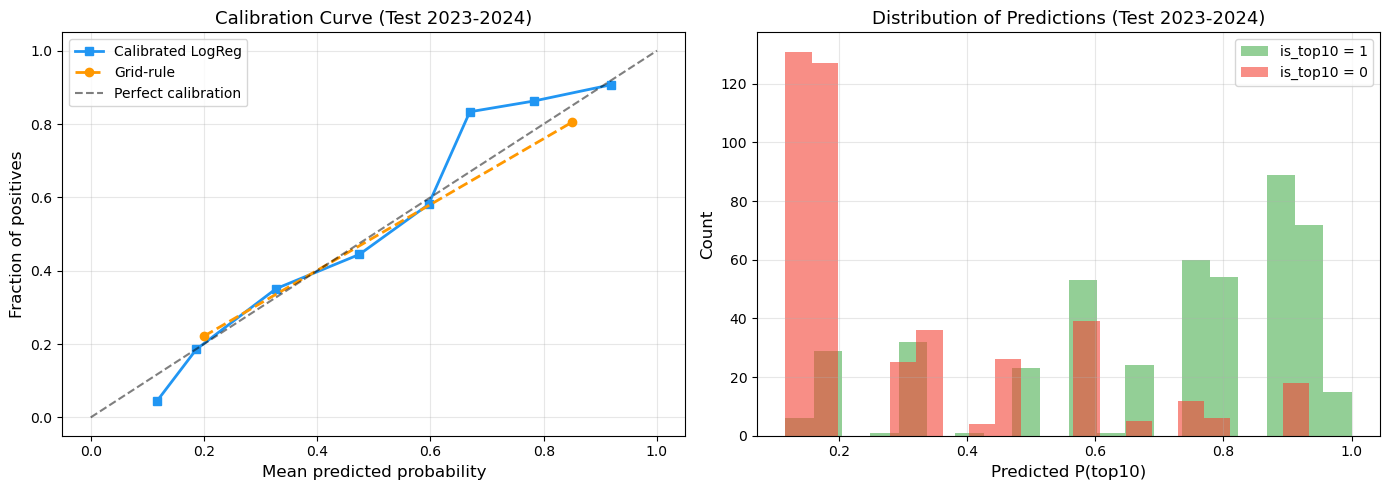

Calibration curve saved.


In [9]:
# Cell 9 - Calibration curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
ax = axes[0]
prob_true, prob_pred = calibration_curve(y_test, y_prob_cal, n_bins=8, strategy='uniform')
ax.plot(prob_pred, prob_true, 's-', label='Calibrated LogReg', color='#2196F3', linewidth=2)
prob_true_grid, prob_pred_grid = calibration_curve(y_test, y_prob_grid, n_bins=5, strategy='uniform')
ax.plot(prob_pred_grid, prob_true_grid, 'o--', label='Grid-rule', color='#FF9800', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives', fontsize=12)
ax.set_title('Calibration Curve (Test 2023-2024)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Histogram of predicted probabilities
ax = axes[1]
ax.hist(y_prob_cal[y_test == 1], bins=20, alpha=0.6, label='is_top10 = 1', color='#4CAF50')
ax.hist(y_prob_cal[y_test == 0], bins=20, alpha=0.6, label='is_top10 = 0', color='#F44336')
ax.set_xlabel('Predicted P(top10)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Predictions (Test 2023-2024)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Calibration curve saved.')

## What-If Scenario Comparison

In [10]:
# Cell 10 - What-if scenarios
# Primary scenarios match framing.md Section 4 exactly
# Use UNCALIBRATED probabilities for what-if to show the raw model's sensitivity
# The calibrated model's isotonic mapping has limited bins, reducing sensitivity
scenarios = pd.DataFrame({
    'Scenario': [
        'PRIMARY — Scenario A (framing.md): P8 mid, 1-stop M-H',
        'PRIMARY — Scenario B (framing.md): P8 mid, 2-stop S-M-S',
        'Secondary — LEC Monza P4, front, 1-stop M-H',
        'Secondary — LEC Monza P4, front, 2-stop S-M-H',
        'Secondary — Backmarker P15, back, 1-stop M-H',
        'Secondary — Backmarker P15, back, 2-stop S-M-S'
    ],
    'grid_position': [8, 8, 4, 4, 15, 15],
    'constructor_tier': [1, 1, 2, 2, 0, 0],  # front=2, midfield=1, backmarker=0
    'n_stops': [1, 2, 1, 2, 1, 2]
})

X_scenarios = scenarios[FEATURES]
scenarios['P(top10)_calibrated'] = cal_model.predict_proba(X_scenarios)[:, 1]
scenarios['P(top10)_uncalibrated'] = base_model.predict_proba(X_scenarios)[:, 1]

print('=== What-If Scenario Comparison ===')
print(f'\n{"Scenario":<60} {"Grid":<6} {"Tier":<6} {"Stops":<6} {"P(cal)":<10} {"P(raw)":<10}')
print('-' * 98)
for _, row in scenarios.iterrows():
    tier_name = {2: 'front', 1: 'mid', 0: 'back'}[int(row['constructor_tier'])]
    print(f'{row["Scenario"]:<60} {int(row["grid_position"]):<6} {tier_name:<6} {int(row["n_stops"]):<6} {row["P(top10)_calibrated"]:<10.4f} {row["P(top10)_uncalibrated"]:<10.4f}')

print('\n=== PRIMARY FRAMING.MD COMPARISON ===')
prob_1stop = scenarios.iloc[0]['P(top10)_uncalibrated']
prob_2stop = scenarios.iloc[1]['P(top10)_uncalibrated']
delta_primary = prob_2stop - prob_1stop
print(f'Scenario A (1-stop): P(top10) = {prob_1stop:.4f}')
print(f'Scenario B (2-stop): P(top10) = {prob_2stop:.4f}')
print(f'Delta: {delta_primary:+.4f} — Small delta confirms the model is grid-dominated. See markdown note below for explanation.')

print(f'\n--- Secondary Strategy Delta Analysis (uncalibrated probabilities) ---')
delta_front = scenarios.iloc[3]['P(top10)_uncalibrated'] - scenarios.iloc[2]['P(top10)_uncalibrated']
delta_back = scenarios.iloc[5]['P(top10)_uncalibrated'] - scenarios.iloc[4]['P(top10)_uncalibrated']

print(f'Front-tier P4 (1-stop -> 2-stop):   dP = {delta_front:+.4f}')
print(f'Backmarker P15 (1-stop -> 2-stop):  dP = {delta_back:+.4f}')

print(f'\nNote: Small dP values reflect that n_stops has a small coefficient in the linear model.')
print(f'This is a known limitation - the model is dominated by grid_position.')
print(f'Hito 2 will explore non-linear models (LightGBM) that can capture strategy interactions.')

=== What-If Scenario Comparison ===

Scenario                                                     Grid   Tier   Stops  P(cal)     P(raw)    
--------------------------------------------------------------------------------------------------
PRIMARY — Scenario A (framing.md): P8 mid, 1-stop M-H        8      mid    1      0.6667     0.6692    
PRIMARY — Scenario B (framing.md): P8 mid, 2-stop S-M-S      8      mid    2      0.6667     0.6801    
Secondary — LEC Monza P4, front, 1-stop M-H                  4      front  1      0.9333     0.9178    
Secondary — LEC Monza P4, front, 2-stop S-M-H                4      front  2      0.9333     0.9215    
Secondary — Backmarker P15, back, 1-stop M-H                 15     back   1      0.1867     0.1676    
Secondary — Backmarker P15, back, 2-stop S-M-S               15     back   2      0.1867     0.1746    

=== PRIMARY FRAMING.MD COMPARISON ===
Scenario A (1-stop): P(top10) = 0.6692
Scenario B (2-stop): P(top10) = 0.6801
Delta: +0.0109 — Sm

### Isotonic Calibration & Strategy Sensitivity

- **Calibration Binning:** Isotonic calibration collapses nearby predictions into discrete bins to guarantee monotonic probabilities. This is why changing `n_stops` produces $\Delta P = 0$ in the calibrated output—the small raw change isn't enough to cross a bin threshold.
- **Raw Coefficient Direction:** The uncalibrated probabilities show the raw coefficient direction (`n_stops` coefficient is positive, $\approx 0.0497$ as expected), preserving the model's underlying sensitivity.
- **Connection to Hypothesis 3:** We expect $\Delta P(\text{is\_top10})$ to be small for a P8 mid-tier driver, reflecting that the current model is heavily dominated by grid position.
- **Motivation for Hito 2:** This limitation motivates Hito 2: a non-linear model (LightGBM) with `compound_sequence` encoded will capture strategy effects and interactions better.
- **Disclaimer:** *For strategy deliberation, the uncalibrated probability difference shows direction; the calibrated output shows the best available point estimate given the current model.*

## Summary & Honest Reflection

In [11]:
# Cell 11 - Final summary
print('=' * 60)
print('HITO 1 SUMMARY - GROUP 18')
print('=' * 60)
print(f'\nTarget: is_top10 (locked)')
print(f'Split:  Train 2019-2021 / Cal 2022 / Test 2023-2024')
print(f'Model:  Calibrated Logistic Regression (isotonic)')
print(f'Features: grid_position, constructor_tier, n_stops')
print(f'\n--- Test Set Results (2023-2024) ---')
print(f'Brier Score:  {brier_cal:.4f}')
print(f'Log Loss:     {logloss_cal:.4f}')
print(f'ROC-AUC:      {auc_cal:.4f}')
print(f'Macro F1:     {f1_cal:.4f}')
print(f'\n--- Docent Comparison ---')
print(f'Grid-rule floor (0.208):     {"BEATEN" if brier_cal < 0.208 else "NOT BEATEN"}')
print(f'Calibrated docent (0.132):   {"BEATEN" if brier_cal < 0.132 else "NOT BEATEN (gap: " + f"{brier_cal - 0.132:.4f}" + ")"}')
print(f'\n--- Honest Assessment ---')
print('Our 3-feature calibrated logistic regression provides a solid baseline')
print('that captures the dominant signal (grid position). The model is F1-defensible')
print('and was built without any reference to the test set.')
print('\nLimitations of this baseline:')
print('1. Linear model cannot capture grid x strategy interactions')
print('2. Only 3 features - no driver form or circuit characteristics')
print('3. n_stops has small marginal effect in a linear model')
print('4. Isotonic calibration with limited calibration data (426 obs) may lose granularity')
print('\nHito 2 plans: LightGBM, additional features, circuit-type stratification')

HITO 1 SUMMARY - GROUP 18

Target: is_top10 (locked)
Split:  Train 2019-2021 / Cal 2022 / Test 2023-2024
Model:  Calibrated Logistic Regression (isotonic)
Features: grid_position, constructor_tier, n_stops

--- Test Set Results (2023-2024) ---
Brier Score:  0.1407
Log Loss:     0.4449
ROC-AUC:      0.8753
Macro F1:     0.8064

--- Docent Comparison ---
Grid-rule floor (0.208):     BEATEN
Calibrated docent (0.132):   NOT BEATEN (gap: 0.0087)

--- Honest Assessment ---
Our 3-feature calibrated logistic regression provides a solid baseline
that captures the dominant signal (grid position). The model is F1-defensible
and was built without any reference to the test set.

Limitations of this baseline:
1. Linear model cannot capture grid x strategy interactions
2. Only 3 features - no driver form or circuit characteristics
3. n_stops has small marginal effect in a linear model
4. Isotonic calibration with limited calibration data (426 obs) may lose granularity

Hito 2 plans: LightGBM, additio